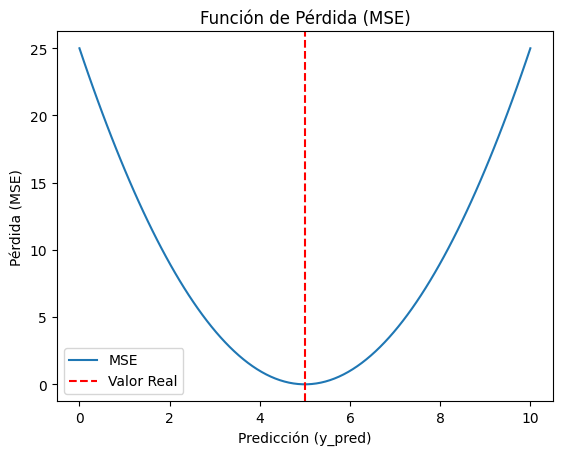

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de ejemplo
y_real = 5  # Valor real
y_pred = np.linspace(0, 10, 100)  # Predicciones posibles
mse = (y_real - y_pred) ** 2  # Función de pérdida (MSE)

# Gráfica
plt.plot(y_pred, mse, label="MSE")
plt.xlabel("Predicción (y_pred)")
plt.ylabel("Pérdida (MSE)")
plt.title("Función de Pérdida (MSE)")
plt.axvline(x=y_real, color="red", linestyle="--", label="Valor Real")
plt.legend()
plt.show()

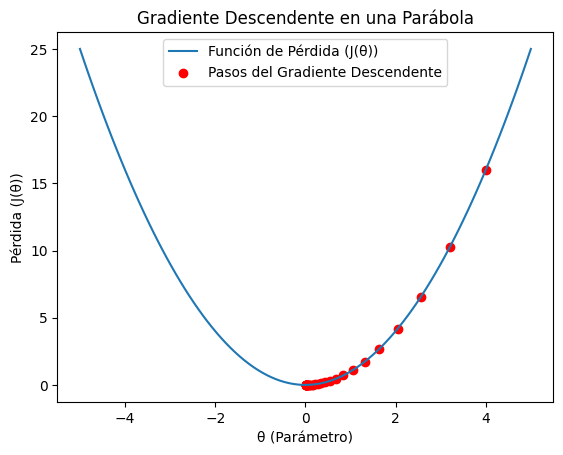

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Función de pérdida y su derivada
def loss(theta):
    return theta**2

def gradient(theta):
    return 2*theta

# Parámetros iniciales
theta = 4  # Valor inicial
eta = 0.1  # Tasa de aprendizaje
steps = 30  # Número de pasos
theta_history = [theta]  # Guardamos los valores de theta

# Gradiente descendente
for _ in range(steps):
    grad = gradient(theta)
    theta = theta - eta * grad
    theta_history.append(theta)

# Gráfica
theta_values = np.linspace(-5, 5, 100)
plt.plot(theta_values, loss(theta_values), label="Función de Pérdida (J(θ))")
plt.scatter(theta_history, [loss(t) for t in theta_history], color="red", label="Pasos del Gradiente Descendente")
plt.xlabel("θ (Parámetro)")
plt.ylabel("Pérdida (J(θ))")
plt.title("Gradiente Descendente en una Parábola")
plt.legend()
plt.show()

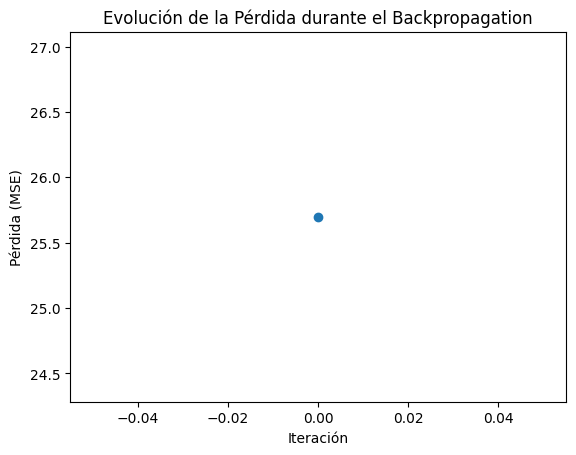

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de ejemplo
X = np.array([[1, 2, 3]])  # Entrada
Y = np.array([[0.5, 0.8]])  # Salida real

# Parámetros iniciales
W1 = np.random.randn(3, 2)  # Pesos capa oculta
b1 = np.random.randn(1, 2)  # Sesgos capa oculta
W2 = np.random.randn(2, 2)  # Pesos capa de salida
b2 = np.random.randn(1, 2)  # Sesgos capa de salida

# Forward Pass
Z1 = np.dot(X, W1) + b1
A1 = np.maximum(0, Z1)  # ReLU
Z2 = np.dot(A1, W2) + b2
Y_pred = Z2  # Regresión lineal

# Función de pérdida (MSE)
loss = np.mean((Y - Y_pred) ** 2)

# Backward Pass
dZ2 = Y_pred - Y
dW2 = np.dot(A1.T, dZ2)
db2 = np.sum(dZ2, axis=0, keepdims=True)
dA1 = np.dot(dZ2, W2.T)
dZ1 = dA1 * (Z1 > 0)  # Derivada de ReLU
dW1 = np.dot(X.T, dZ1)
db1 = np.sum(dZ1, axis=0, keepdims=True)

# Actualización de parámetros
eta = 0.1  # Tasa de aprendizaje
W1 -= eta * dW1
b1 -= eta * db1
W2 -= eta * dW2
b2 -= eta * db2

# Gráfica de la función de pérdida
plt.plot(loss, marker="o")
plt.xlabel("Iteración")
plt.ylabel("Pérdida (MSE)")
plt.title("Evolución de la Pérdida durante el Backpropagation")
plt.show()

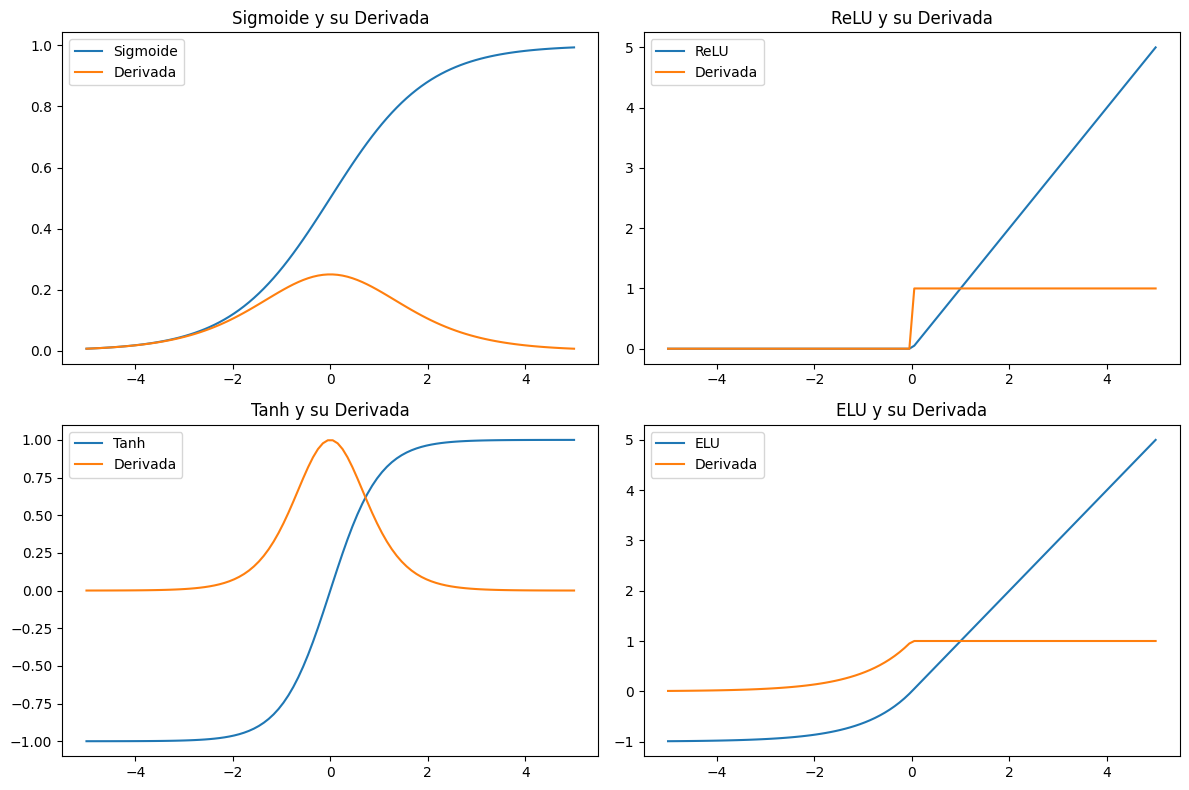

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de funciones
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2

# Rango de valores de z
z = np.linspace(-5, 5, 100)

# Gráficas
plt.figure(figsize=(12, 8))

# Sigmoide
plt.subplot(2, 2, 1)
plt.plot(z, sigmoid(z), label="Sigmoide")
plt.plot(z, sigmoid_derivative(z), label="Derivada")
plt.title("Sigmoide y su Derivada")
plt.legend()

# ReLU
plt.subplot(2, 2, 2)
plt.plot(z, relu(z), label="ReLU")
plt.plot(z, relu_derivative(z), label="Derivada")
plt.title("ReLU y su Derivada")
plt.legend()

# Tanh
plt.subplot(2, 2, 3)
plt.plot(z, tanh(z), label="Tanh")
plt.plot(z, tanh_derivative(z), label="Derivada")
plt.title("Tanh y su Derivada")
plt.legend()

# ELU (α = 1)
plt.subplot(2, 2, 4)
alpha = 1
elu = np.where(z > 0, z, alpha * (np.exp(z) - 1))
elu_derivative = np.where(z > 0, 1, alpha * np.exp(z))
plt.plot(z, elu, label="ELU")
plt.plot(z, elu_derivative, label="Derivada")
plt.title("ELU y su Derivada")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

# Definición de la red neuronal
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(3, 2)  # Capa oculta con 2 neuronas
        self.output = nn.Linear(2, 2)  # Capa de salida con 2 neuronas
    
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = self.output(x)  # Sin activación para regresión o softmax para clasificación
        return x

# Creación del modelo
model = SimpleNN()

# Definición de la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Para regresión, usar CrossEntropyLoss para clasificación
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Datos de ejemplo
X_train = torch.tensor([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9]], dtype=torch.float32)
y_train = torch.tensor([[0.5, 0.7], [0.2, 0.3], [0.9, 1.0]], dtype=torch.float32)

# Entrenamiento de la red neuronal
for epoch in range(1000):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluación del modelo
print("Salida final:", model(X_train).detach().numpy())

Salida final: [[0.3333333  0.5166667 ]
 [0.53333336 0.6666667 ]
 [0.7333333  0.8166666 ]]


Salida final: [[0.34999973 0.50000006]
 [0.34999973 0.50000006]
 [0.9        1.        ]]


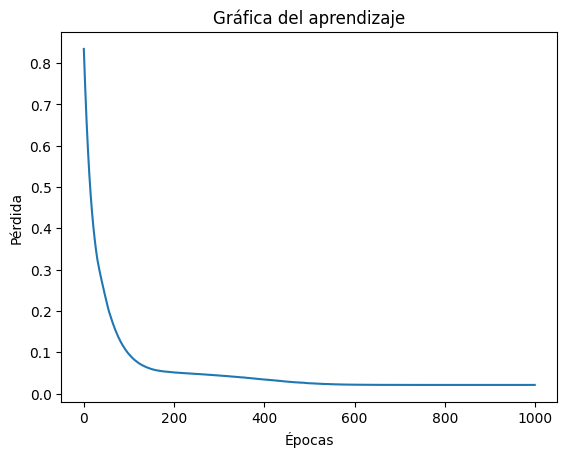

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Definición de la red neuronal
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(3, 2)  # Capa oculta con 2 neuronas
        self.output = nn.Linear(2, 2)  # Capa de salida con 2 neuronas
    
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = self.output(x)  # Sin activación para regresión o softmax para clasificación
        return x

# Creación del modelo
model = SimpleNN()

# Definición de la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Para regresión, usar CrossEntropyLoss para clasificación
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Datos de ejemplo
X_train = torch.tensor([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9]], dtype=torch.float32)
y_train = torch.tensor([[0.5, 0.7], [0.2, 0.3], [0.9, 1.0]], dtype=torch.float32)

# Lista para almacenar las pérdidas
losses = []

# Entrenamiento de la red neuronal
for epoch in range(1000):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    
    # Guardar la pérdida de la época actual
    losses.append(loss.item())

# Evaluación del modelo
print("Salida final:", model(X_train).detach().numpy())

# Dibujar la gráfica del aprendizaje
plt.plot(losses)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Gráfica del aprendizaje')
plt.show()

In [15]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Definir el modelo en Keras
model = keras.Sequential([
    keras.layers.Dense(2, activation='relu', input_shape=(3,)),
    keras.layers.Dense(2, activation='linear')  # Sin activación para regresión
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Datos de entrenamiento
X_train = np.array([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9]])
y_train = np.array([[0.5, 0.7], [0.2, 0.3], [0.9, 1.0]])

# Entrenar el modelo
model.fit(X_train, y_train, epochs=1000, verbose=0)

# Evaluación del modelo
print("Salida final:", model.predict(X_train))

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import math

# Create random input and output data
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

# Randomly initialize weights
np.random.seed(0)
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

learning_rate = 0.000001
for t in range(5000):
    # Forward pass: compute predicted y
    # y = a + b x + c x^2 + d x^3
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss
    loss = np.square(y_pred - y).sum()
    if t % 100 == 99:
        print(t, loss)

    # Backprop to compute gradients of a, b, c, d with respect to loss
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()

    # Update weights
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3')

99 1942.5981197543472
199 1357.8620988723726
299 950.6459714997519
399 666.8234472515073
499 468.84881983428795
599 330.65138961169055
699 234.11186628462443
799 166.62610469569785
899 119.4189117419541
999 86.37582610337255
1099 63.23296761101651
1199 47.01467134962145
1299 35.642761530587755
1399 27.664836288357098
1499 22.065150545580426
1599 18.132878187057905
1699 15.370270373477139
1799 13.428577985505335
1899 12.06331164944789
1999 11.10298121439451
2099 10.427238550270934
2199 9.951585066391548
2299 9.616665548063287
2399 9.380768352059482
2499 9.21456869541513
2599 9.097442152314418
2699 9.014877990592938
2799 8.956663325910238
2899 8.915607796566082
2999 8.886647465712102
3099 8.86621492029699
3199 8.851796313566776
3299 8.841619752263146
3399 8.834436004451678
3499 8.829364124493745
3599 8.825782743193297
3699 8.823253492104275
3799 8.821467048031728
3899 8.820205105670185
3999 8.819313569526074
4099 8.818683650611177
4199 8.818238534099978
4299 8.8179239741734
4399 8.817701

In [ ]:
# -*- coding: utf-8 -*-

import torch
import math


dtype = torch.float
device = torch.device("cpu")
# device = torch.device("cuda:0") # Uncomment this to run on GPU

# Create random input and output data
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)

torch.manual_seed(0)
# Randomly initialize weights
a = torch.randn((), device=device, dtype=dtype)
b = torch.randn((), device=device, dtype=dtype)
c = torch.randn((), device=device, dtype=dtype)
d = torch.randn((), device=device, dtype=dtype)

learning_rate = 1e-6
for t in range(10000):
    # Forward pass: compute predicted y
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss
    loss = (y_pred - y).pow(2).sum().item()
    if t % 100 == 99:
        print(t, loss)

    # Backprop to compute gradients of a, b, c, d with respect to loss
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()

    # Update weights using gradient descent
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d


print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

99 3238.300537109375
199 2245.867431640625
299 1559.9361572265625
399 1085.354248046875
499 756.6680908203125
599 528.8026733398438
699 370.6806640625
799 260.8537292480469
899 184.50198364257812
999 131.3756866455078
1099 94.3787612915039
1199 68.59319305419922
1299 50.60741424560547
1399 38.052650451660156
1499 29.282577514648438
1599 23.15198516845703
1699 18.86368179321289
1799 15.86209487915039
1899 13.759875297546387
1999 12.286677360534668
2099 11.253724098205566
2199 10.529075622558594
2299 10.020448684692383
2399 9.663276672363281
2499 9.412354469299316
2599 9.235995292663574
2699 9.111990928649902
2799 9.024767875671387
2899 8.963396072387695
2999 8.920195579528809
3099 8.889778137207031
3199 8.868352890014648
3299 8.853259086608887
3399 8.842621803283691
3499 8.835123062133789
3599 8.829835891723633
3699 8.826107025146484
3799 8.82347583770752
3899 8.821621894836426
3999 8.8203125
4099 8.819387435913086
4199 8.81873607635498
4299 8.818275451660156
4399 8.817949295043945
4499

In [ ]:
torch.accelerator.is_available()

False

In [ ]:
# -*- coding: utf-8 -*-
import torch
import math

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

# Create Tensors to hold input and outputs.
# By default, requires_grad=False, which indicates that we do not need to
# compute gradients with respect to these Tensors during the backward pass.
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
y = torch.sin(x)

# Create random Tensors for weights. For a third order polynomial, we need
# 4 weights: y = a + b x + c x^2 + d x^3
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
torch.random.manual_seed(0)
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)

learning_rate = 1e-6
for t in range(10000):
    # Forward pass: compute predicted y using operations on Tensors.
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss using operations on Tensors.
    # Now loss is a Tensor of shape (1,)
    # loss.item() gets the scalar value held in the loss.
    loss = (y_pred - y).pow(2).sum()
    if t % 100 == 99:
        print(t, loss.item())

    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Tensors with requires_grad=True.
    # After this call a.grad, b.grad. c.grad and d.grad will be Tensors holding
    # the gradient of the loss with respect to a, b, c, d respectively.
    loss.backward()

    # Manually update weights using gradient descent. Wrap in torch.no_grad()
    # because weights have requires_grad=True, but we don't need to track this
    # in autograd.
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

Using cpu device
99 3238.300537109375
199 2245.867431640625
299 1559.9361572265625
399 1085.354248046875
499 756.6680908203125
599 528.8026733398438
699 370.6806640625
799 260.8537292480469
899 184.50198364257812
999 131.3756866455078
1099 94.3787612915039
1199 68.59319305419922
1299 50.60741424560547
1399 38.052650451660156
1499 29.282577514648438
1599 23.15198516845703
1699 18.86368179321289
1799 15.86209487915039
1899 13.759875297546387
1999 12.286677360534668
2099 11.253724098205566
2199 10.529075622558594
2299 10.020448684692383
2399 9.663276672363281
2499 9.412354469299316
2599 9.235995292663574
2699 9.111990928649902
2799 9.024767875671387
2899 8.963396072387695
2999 8.920195579528809
3099 8.889778137207031
3199 8.868352890014648
3299 8.853259086608887
3399 8.842621803283691
3499 8.835123062133789
3599 8.829835891723633
3699 8.826107025146484
3799 8.82347583770752
3899 8.821621894836426
3999 8.8203125
4099 8.819387435913086
4199 8.81873607635498
4299 8.818275451660156
4399 8.817

Using cpu device
99 3238.300537109375
199 2245.867431640625
299 1559.9361572265625
399 1085.354248046875
499 756.6680908203125
599 528.8026733398438
699 370.6806640625
799 260.8537292480469
899 184.50198364257812
999 131.3756866455078
1099 94.3787612915039
1199 68.59319305419922
1299 50.60741424560547
1399 38.052650451660156
1499 29.282577514648438
1599 23.15198516845703
1699 18.86368179321289
1799 15.86209487915039
1899 13.759875297546387
1999 12.286677360534668
2099 11.253724098205566
2199 10.529075622558594
2299 10.020448684692383
2399 9.663276672363281
2499 9.412354469299316
2599 9.235995292663574
2699 9.111990928649902
2799 9.024767875671387
2899 8.963396072387695
2999 8.920195579528809
3099 8.889778137207031
3199 8.868352890014648
3299 8.853259086608887
3399 8.842621803283691
3499 8.835123062133789
3599 8.829835891723633
3699 8.826107025146484
3799 8.82347583770752
3899 8.821621894836426
3999 8.8203125
4099 8.819387435913086
4199 8.81873607635498
4299 8.818275451660156
4399 8.817

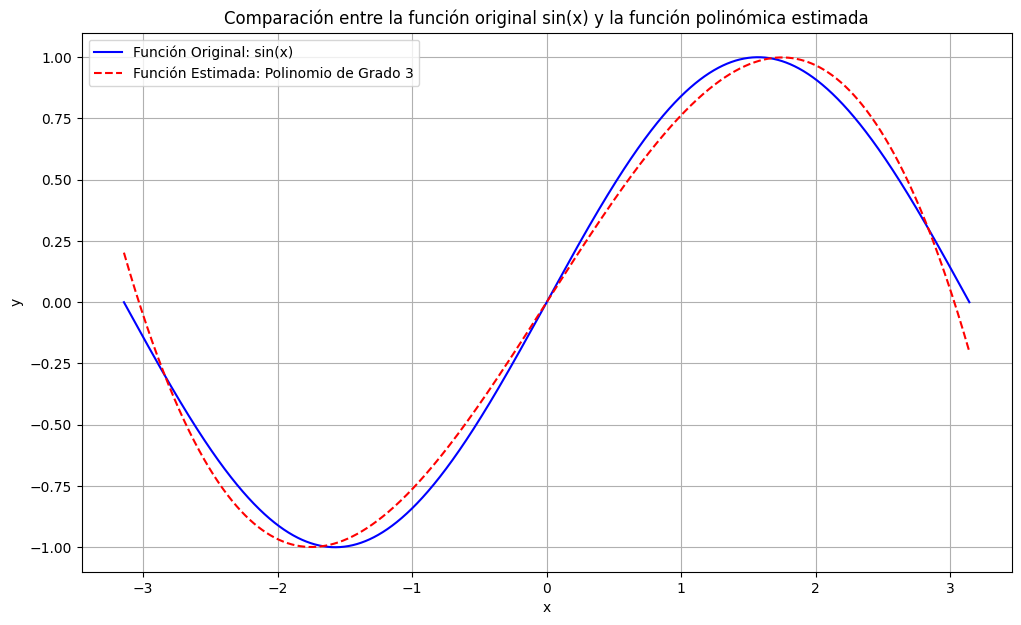

In [21]:
# -*- coding: utf-8 -*-
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

dtype = torch.float
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

# Create Tensors to hold input and outputs.
# By default, requires_grad=False, which indicates that we do not need to
# compute gradients with respect to these Tensors during the backward pass.
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
y_sin_original = torch.sin(x) # Store the original sin(x) function

# Create random Tensors for weights. For a third order polynomial, we need
# 4 weights: y = a + b x + c x^2 + d x^3
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
torch.random.manual_seed(0)
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)

learning_rate = 1e-6
for t in range(10000):
    # Forward pass: compute predicted y using operations on Tensors.
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss using operations on Tensors.
    # Now loss is a Tensor of shape (1,)
    # loss.item() gets the scalar value held in the loss.
    loss = (y_pred - y_sin_original).pow(2).sum() # Use y_sin_original here
    if t % 100 == 99:
        print(t, loss.item())

    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Tensors with requires_grad=True.
    # After this call a.grad, b.grad. c.grad and d.grad will be Tensors holding
    # the gradient of the loss with respect to a, b, c, d respectively.
    loss.backward()

    # Manually update weights using gradient descent. Wrap in torch.no_grad()
    # because weights have requires_grad=True, but we don't need to track this
    # in autograd.
    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

# Calculate the estimated function using the learned weights
y_polynomial_estimated = a + b * x + c * x ** 2 + d * x ** 3

# Pintar las funciones
plt.figure(figsize=(12, 7))
plt.plot(x.cpu().numpy(), y_sin_original.cpu().numpy(), label='Función Original: sin(x)', color='blue')
plt.plot(x.cpu().numpy(), y_polynomial_estimated.detach().cpu().numpy(), label='Función Estimada: Polinomio de Grado 3', color='red', linestyle='--') # Use detach() here

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparación entre la función original sin(x) y la función polinómica estimada')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [24]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

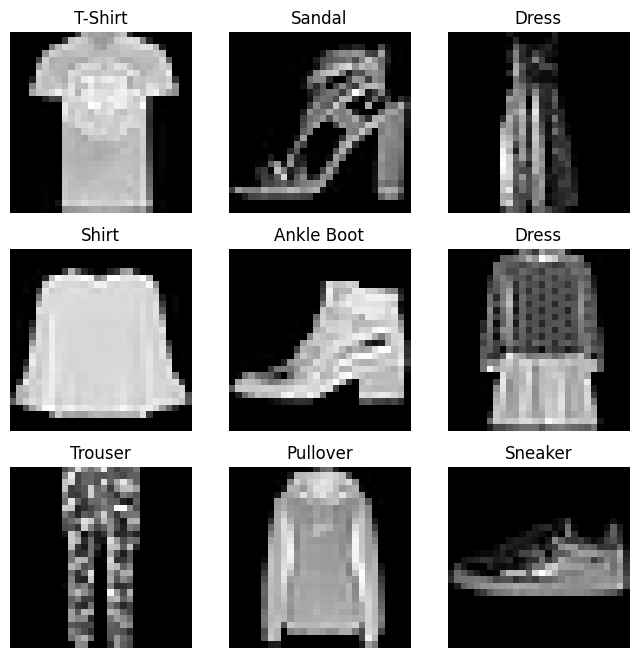

In [25]:
# mostrar algunas de las imágenes del dataset Fashion MNISR

import matplotlib.pyplot as plt

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3  # Número de columnas y filas a mostrar
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [26]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [27]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [30]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [31]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    

In [32]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.292694  [   64/60000]
loss: 2.282913  [ 6464/60000]
loss: 2.261839  [12864/60000]
loss: 2.260842  [19264/60000]
loss: 2.243933  [25664/60000]
loss: 2.213160  [32064/60000]
loss: 2.217486  [38464/60000]
loss: 2.186190  [44864/60000]
loss: 2.184339  [51264/60000]
loss: 2.151588  [57664/60000]
Test Error: 
 Accuracy: 52.6%, Avg loss: 2.143376 

Epoch 2
-------------------------------
loss: 2.155766  [   64/60000]
loss: 2.146133  [ 6464/60000]
loss: 2.084366  [12864/60000]
loss: 2.099236  [19264/60000]
loss: 2.054477  [25664/60000]
loss: 1.988882  [32064/60000]
loss: 2.014589  [38464/60000]
loss: 1.943700  [44864/60000]
loss: 1.947330  [51264/60000]
loss: 1.863964  [57664/60000]
Test Error: 
 Accuracy: 59.6%, Avg loss: 1.869596 

Epoch 3
-------------------------------
loss: 1.907473  [   64/60000]
loss: 1.877431  [ 6464/60000]
loss: 1.761152  [12864/60000]
loss: 1.791686  [19264/60000]
loss: 1.681296  [25664/60000]
loss: 1.637747  [32064/600

In [33]:
torch.save(model.state_dict(),"model.pth")
print("modelo MyTorch guardado en model.pth")

modelo MyTorch guardado en model.pth


In [35]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth",weights_only=True))

<All keys matched successfully>

In [39]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[20][0], test_data[20][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Shirt", Actual: "Pullover"


In [40]:
import torch
import numpy as np



In [41]:
data = [[1,2],[3,4]]
x_data= torch.tensor(data)

In [42]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [43]:
print(x_data)

tensor([[1, 2],
        [3, 4]])


In [44]:
print(x_np)

tensor([[1, 2],
        [3, 4]])


In [51]:
x_ones = torch.ones_like(x_data) 
print(f"Tensor de unos: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) 
print(f"Tensor de aleatorios: \n {x_rand} \n")


Tensor de unos: 
 tensor([[1, 1],
        [1, 1]]) 

Tensor de aleatorios: 
 tensor([[0.1642, 0.6888],
        [0.9009, 0.7221]]) 



In [52]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Tensor de aleatorios: \n {rand_tensor} \n")
print(f"Tensor de unos: \n {ones_tensor} \n")
print(f"Tensor de ceros: \n {zeros_tensor} \n")

Tensor de aleatorios: 
 tensor([[0.4288, 0.6804, 0.9540],
        [0.5867, 0.9894, 0.9631]]) 

Tensor de unos: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Tensor de ceros: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 



In [53]:
print(f"Forma del tensor {rand_tensor.shape}")
print(f"Tipo de datos del tensor {rand_tensor.dtype}")
print(f"Dispositivo que almacena el tensor {rand_tensor.device}")


Forma del tensor torch.Size([2, 3])
Tipo de datos del tensor torch.float32
Dispositivo que almacena el tensor cpu


In [57]:
# We move our tensor to the current accelerator if available
if torch.accelerator.is_available():
    rand_tensor = rand_tensor.to(torch.accelerator.current_accelerator())

print(rand_tensor)

tensor([[0.4288, 0.6804, 0.9540],
        [0.5867, 0.9894, 0.9631]])


In [58]:
torch.__version__

'2.6.0+cpu'